# Lab 4 (OPT-2) — SGD Noise, Mini-batches, Momentum/Nesterov, and SGLD (SDE Intuition)

**Course:** Mathematical Foundations of Machine and Deep Learning (beginner+)  
**Format:** 1.5h guided lab (Colab/Jupyter)  
**Libraries:** numpy, matplotlib (seaborn optional)

**Content (what this lab is about):**
In this lab, we optimize a synthetic empirical risk problem and learn why SGD behaves differently from full-batch gradient descent.
We explore how mini-batch size controls the amount of noise in updates and how this affects stability and convergence.
We then add momentum and Nesterov acceleration to improve optimization dynamics.
Finally, we implement SGLD as an SDE-inspired method that adds temperature-driven noise for exploration on a non-convex 2D objective.


## Learning objectives (you should be able to...)
1. Define empirical risk and implement full-batch gradient descent on a toy regression task.
2. Implement SGD with mini-batches and explain how batch size affects update noise and stability.
3. Implement momentum and Nesterov updates and interpret them as “velocity” methods (heavy-ball intuition).
4. Implement SGLD and explain the role of temperature (exploration vs convergence).

## Minute-by-minute plan (90 min total)
- **Intro (10 min):** Empirical risk, why SGD is noisy, batch size trade-offs, momentum/Nesterov intuition, SGLD idea
- **Hands-on (70 min):**
  - Module 1 (10–12): synthetic regression + full-batch GD baseline
  - Module 2 (18–20): SGD + batch size sweep
  - Module 3 (18–20): momentum + Nesterov
  - Module 4 (15–18): SGLD on a 2D non-convex function + contour trajectories
  - Module 5 (3–5): micro reflection
- **Wrap-up (10 min):** key takeaways + tuning checklist + concept questions


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Optional (allowed), but not required:
try:
    import seaborn as sns
    _HAS_SEABORN = True
except Exception:
    _HAS_SEABORN = False

np.random.seed(42)

def plot_loss_curve(loss_history, title="Loss curve"):
    """Plot loss vs update step."""
    if loss_history is None or len(loss_history) == 0:
        print("Nothing to plot: loss_history is empty.")
        return
    plt.figure()
    plt.plot(loss_history)
    plt.xlabel("Update step")
    plt.ylabel("Full loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_w_path_2d(history, title="w-path (w1 vs w2)"):
    """Plot parameter trajectory in 2D (first two coordinates)."""
    if history is None or len(history) == 0:
        print("Nothing to plot: history is empty.")
        return
    H = np.array(history)
    if H.shape[1] < 2:
        print("Need at least 2D parameters to plot w1 vs w2.")
        return
    plt.figure()
    plt.plot(H[:, 0], H[:, 1], marker="o", markersize=2, linewidth=1)
    plt.xlabel("w1")
    plt.ylabel("w2")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

def contour_with_trajectory(f, xlim, ylim, traj, title="Contour + trajectory", levels=40):
    """Contour plot for a 2D function + a trajectory path."""
    xs = np.linspace(xlim[0], xlim[1], 250)
    ys = np.linspace(ylim[0], ylim[1], 250)
    X, Y = np.meshgrid(xs, ys)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = f(np.array([X[i, j], Y[i, j]]))

    plt.figure()
    plt.contour(X, Y, Z, levels=levels)
    if traj is not None and len(traj) > 0:
        T = np.array(traj)
        plt.plot(T[:, 0], T[:, 1], marker="o", markersize=2, linewidth=1)
        plt.scatter([T[0, 0]], [T[0, 1]], s=50, marker="s", label="start")
        plt.scatter([T[-1, 0]], [T[-1, 1]], s=50, marker="*", label="end")
        plt.legend()
    plt.xlabel("w1")
    plt.ylabel("w2")
    plt.title(title)
    plt.grid(True, alpha=0.2)
    plt.show()


## Intro (10 min): key ideas (instructor notes)

### Empirical risk (ERM)
We often optimize an objective of the form:
\[
F(w) = \frac{1}{n}\sum_{i=1}^n \ell_i(w)
\]
where each \(\ell_i\) is the loss from one training example (data point).

### Why SGD introduces noise
Full-batch gradient uses all data to compute \(\nabla F(w)\).  
SGD uses only a subset (mini-batch), so its gradient estimate is noisy:
\[
g(w) \approx \nabla F(w)
\]
The smaller the batch, the higher the variance of this estimate.

### Batch size trade-offs
- Small batch: cheaper updates, more noise, sometimes better exploration but less stable.
- Large batch: more stable and accurate gradients, but each update is more expensive.

### Momentum / Nesterov = “velocity” (heavy-ball intuition)
Instead of moving directly opposite to the gradient, we maintain a velocity vector `v` that accumulates past gradients.
This can reduce zig-zagging in narrow valleys and speed up progress along consistent directions.

### SGLD (SDE intuition)
SGLD adds Gaussian noise to the SGD update:
\[
w_{k+1} = w_k - \eta \nabla f(w_k) + \sqrt{2\eta T}\,\xi_k,\quad \xi_k \sim \mathcal{N}(0, I)
\]
- `T` (temperature) controls exploration.
- Too much noise prevents convergence; moderate noise can escape shallow minima on non-convex landscapes.


## MODULE 1 — Synthetic empirical risk setup + full-batch GD baseline (10–12 min)

We create a synthetic linear regression dataset:
- \(A \in \mathbb{R}^{n\times d}\)
- true parameters `true_w`
- targets \(b = A\,true_w + \epsilon\)

We will optimize mean squared error (MSE) empirical risk:
\[
F(w) = \frac{1}{n}\sum_{i=1}^n (a_i^\top w - b_i)^2
\]

**Goal:** Implement `full_loss`, `full_grad`, and a single GD step.
Then run full-batch GD as a baseline and plot the loss curve.


In [2]:
# Synthetic regression data
n = 256
d = 10

A = np.random.randn(n, d)
true_w = np.random.randn(d)
noise_sigma = 0.3
b = A @ true_w + noise_sigma * np.random.randn(n)

# We'll also track only the first 2 coords for w-path plots in some experiments
print("A shape:", A.shape, "b shape:", b.shape, "true_w[:3]:", true_w[:3])


A shape: (256, 10) b shape: (256,) true_w[:3]: [-1.01389595  0.08568716 -0.92542463]


### Task 1 — Implement `full_loss(w)` (MSE)

`full_loss(w)` should return the **mean** squared error over all samples.
Keep it simple: compute residuals `r = A @ w - b` and return `mean(r^2)`.

**What do you observe?**
- When `w = true_w`, the loss should be close to noise variance (not exactly 0 because of noise).

**Expected takeaway:** even perfect parameters can’t reach zero loss when targets include noise.


In [3]:
def full_loss(w, A=A, b=b):
    # TODO: implement full-batch MSE loss: mean((A@w - b)^2)
    # --- SOLUTION (instructor) ---
    # r = A @ w - b
    # return np.mean(r**2)

    # fallback so the notebook runs
    r = A @ w - b
    return float(np.mean(r**2))

w_test = np.zeros(d)
print("Loss at w=0:", full_loss(w_test))
print("Loss at w=true_w:", full_loss(true_w))


Loss at w=0: 4.880131296828047
Loss at w=true_w: 0.08073357665586546


### Task 2 — Implement `full_grad(w)`

For MSE:
\[
F(w) = \frac{1}{n}\|A w - b\|^2
\quad\Rightarrow\quad
\nabla F(w) = \frac{2}{n} A^\top(Aw - b)
\]

**What do you observe?**
- The gradient should be a vector of shape `(d,)`.

**Expected takeaway:** gradients are linear-algebra friendly (matrix-vector operations).


In [4]:
def full_grad(w, A=A, b=b):
    # TODO: implement gradient of mean squared error: (2/n) * A.T @ (A@w - b)
    # --- SOLUTION (instructor) ---
    # n = A.shape[0]
    # r = A @ w - b
    # return (2.0 / n) * (A.T @ r)

    # fallback so the notebook runs
    n_ = A.shape[0]
    r = A @ w - b
    return (2.0 / n_) * (A.T @ r)

g_test = full_grad(np.zeros(d))
print("Grad shape:", g_test.shape, "||grad||:", np.linalg.norm(g_test))


Grad shape: (10,) ||grad||: 4.224941734633357


### Task 3 — Implement one GD update step and run full-batch GD baseline

One GD step:
\[
w \leftarrow w - \text{lr}\cdot \nabla F(w)
\]

We will store:
- `history`: list of `w` after each update
- `loss_history`: full loss after each update

**Expected takeaway:** full-batch GD produces a smooth (low-noise) loss curve and parameter path.


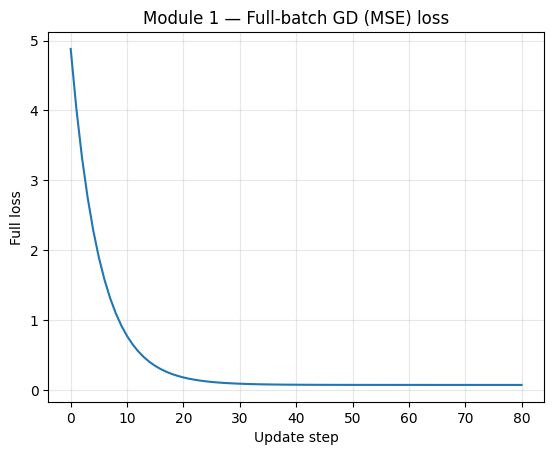

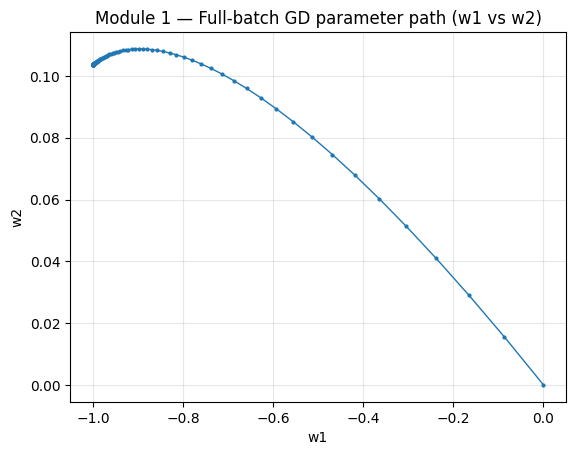

In [5]:
def gd_step(w, lr):
    # TODO: implement one GD update step using full_grad(w)
    # --- SOLUTION (instructor) ---
    # return w - lr * full_grad(w)

    # fallback so the notebook runs
    return w - lr * full_grad(w)

def full_batch_gd(w0, lr=0.05, iters=80):
    w = w0.copy()
    history = [w.copy()]
    loss_history = [full_loss(w)]
    for _ in range(iters):
        w = gd_step(w, lr)
        history.append(w.copy())
        loss_history.append(full_loss(w))
    return history, loss_history

w0 = np.zeros(d)
history_gd, loss_gd = full_batch_gd(w0, lr=0.05, iters=80)

plot_loss_curve(loss_gd, title="Module 1 — Full-batch GD (MSE) loss")
plot_w_path_2d(history_gd, title="Module 1 — Full-batch GD parameter path (w1 vs w2)")


## MODULE 2 — SGD with mini-batches + batch size sweep (18–20 min)

Now we implement **SGD** for the same empirical risk:
- Each update uses a mini-batch of indices.
- We shuffle indices each epoch.
- We store `history` and `loss_history` after each update (full loss, for comparability).

**Key experiment:** compare `batch_size` in `{1, 16, n}` and observe:
- noise level in loss curve
- noisiness of parameter path (w1-w2 trace)

**Important:** This notebook must run even if TODOs are not filled — we include fallbacks.


### Task 1 — Implement `minibatch_grad(w, idx)`

For a batch `idx` (array of indices), compute gradient of the MSE **over that batch**:
\[
g_{\mathcal{B}}(w)=\frac{2}{|\mathcal{B}|}A_\mathcal{B}^\top(A_\mathcal{B}w - b_\mathcal{B})
\]

**What do you observe?**
- For smaller batches, the gradient estimate varies more from step to step.

**Expected takeaway:** mini-batch gradients are noisy estimates of the full gradient.


In [6]:
def minibatch_grad(w, idx, A=A, b=b):
    # TODO: implement batch gradient of MSE on indices idx
    # --- SOLUTION (instructor) ---
    # Ab = A[idx]
    # bb = b[idx]
    # m = Ab.shape[0]
    # r = Ab @ w - bb
    # return (2.0 / m) * (Ab.T @ r)

    # fallback so the notebook runs
    Ab = A[idx]
    bb = b[idx]
    m = Ab.shape[0]
    r = Ab @ w - bb
    return (2.0 / m) * (Ab.T @ r)


### Task 2–3 — Implement `sgd(...)` update + logging

We implement:
- shuffle indices each epoch
- iterate through mini-batches
- update `w <- w - lr * minibatch_grad(...)`
- append to `history` and `loss_history` after **each update**

**What do you observe?**
- With `batch_size=1`, loss curve is bumpy and path is “wiggly”.
- With `batch_size=n`, SGD matches full-batch GD.

**Expected takeaway:** batch size controls gradient variance → controls optimization noise.


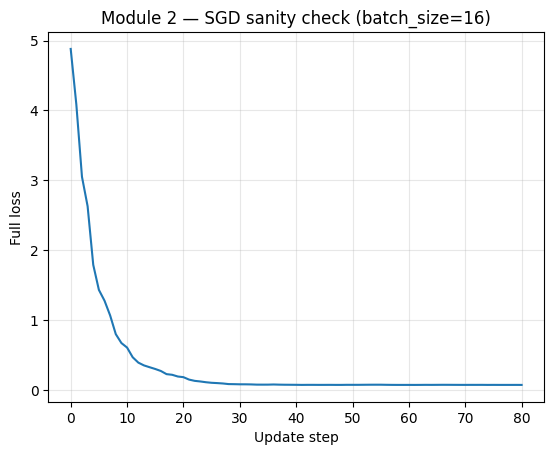

In [7]:
def sgd(w0, lr=0.05, epochs=10, batch_size=16, seed=123):
    rng = np.random.default_rng(seed)
    w = w0.copy()
    history = [w.copy()]
    loss_history = [full_loss(w)]

    n_ = A.shape[0]
    idx_all = np.arange(n_)

    for _ in range(epochs):
        rng.shuffle(idx_all)
        # iterate mini-batches
        for start in range(0, n_, batch_size):
            batch_idx = idx_all[start:start+batch_size]

            # TODO: compute mini-batch gradient and do SGD update
            # --- SOLUTION (instructor) ---
            # g = minibatch_grad(w, batch_idx)
            # w = w - lr * g

            # fallback so the notebook runs
            g = minibatch_grad(w, batch_idx)
            w = w - lr * g

            # TODO: store w in history and full loss in loss_history (after each update)
            # --- SOLUTION (instructor) ---
            # history.append(w.copy())
            # loss_history.append(full_loss(w))

            # fallback so the notebook runs
            history.append(w.copy())
            loss_history.append(full_loss(w))

    return history, loss_history

# Quick sanity run
hist_sgd, loss_sgd = sgd(np.zeros(d), lr=0.05, epochs=5, batch_size=16, seed=1)
plot_loss_curve(loss_sgd, title="Module 2 — SGD sanity check (batch_size=16)")


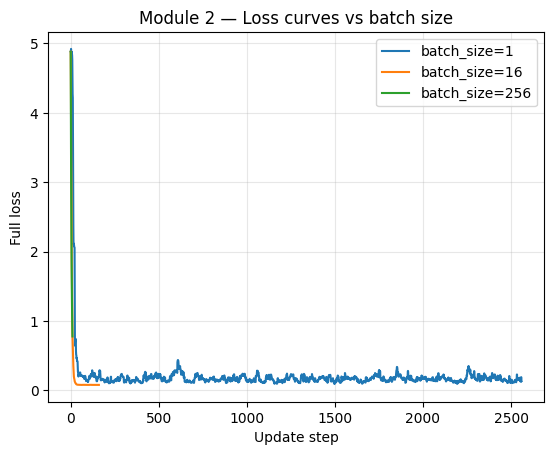

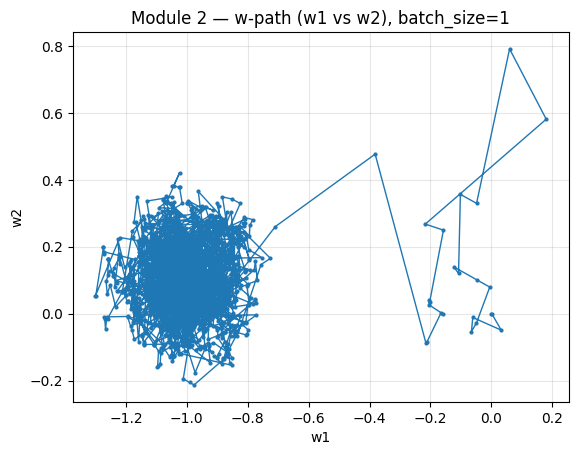

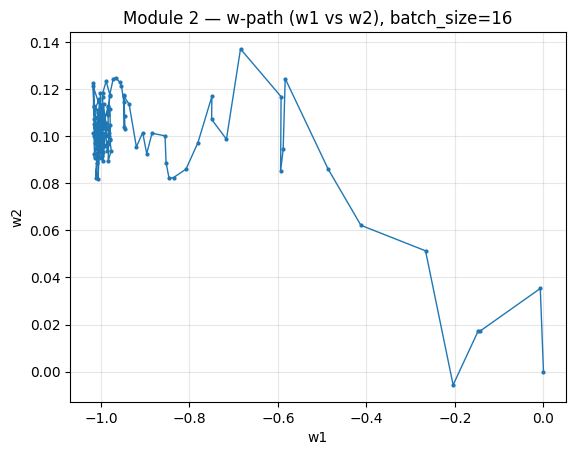

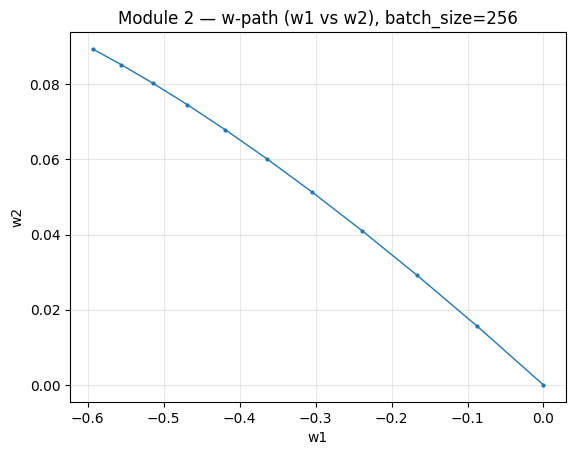

In [8]:
w0 = np.zeros(d)

batch_sizes = [1, 16, n]  # n means full-batch (one update per epoch)
results = {}

for bs in batch_sizes:
    hist, loss_hist = sgd(w0, lr=0.05, epochs=10, batch_size=bs, seed=7)
    results[bs] = (hist, loss_hist)

# Loss curves comparison
plt.figure()
for bs in batch_sizes:
    _, loss_hist = results[bs]
    plt.plot(loss_hist, label=f"batch_size={bs}")
plt.xlabel("Update step")
plt.ylabel("Full loss")
plt.title("Module 2 — Loss curves vs batch size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# w1-w2 traces comparison
for bs in batch_sizes:
    hist, _ = results[bs]
    plot_w_path_2d(hist, title=f"Module 2 — w-path (w1 vs w2), batch_size={bs}")


### What do you observe? (Module 2)

1. Compare the **smoothness** of loss curves for `batch_size=1` vs `16` vs `n`.
2. Compare the **wiggliness** of the w1–w2 parameter paths.
3. Does a noisier path always mean worse final loss?

### Expected takeaway
- Smaller batches inject more noise → bumpy loss curves and noisy parameter trajectories.
- Larger batches reduce variance → smoother curves, but fewer updates per epoch for the same compute.
- In practice, moderate noise can help exploration early, but too much noise can slow convergence.


## MODULE 3 — Momentum and Nesterov (18–20 min)

### Heavy-ball (momentum) intuition
We keep a “velocity” vector `v` that accumulates gradients:
- **Momentum (heavy-ball):**
  \[
  v \leftarrow \mu v - \eta g(w), \quad w \leftarrow w + v
  \]
`mu` (often 0.9) controls how much past velocity we keep.

### Nesterov (lookahead) intuition
Nesterov computes gradient at a *lookahead* point:
- **Nesterov:**
  \[
  g \leftarrow \nabla f(w + \mu v), \quad
  v \leftarrow \mu v - \eta g, \quad
  w \leftarrow w + v
  \]

**Goal:** extend SGD to support momentum and Nesterov; compare loss curves and trajectories.


### Task 1–2 — Implement momentum and Nesterov options

We extend SGD with parameters:
- `use_momentum: bool`
- `mu: float` (default 0.9)
- `nesterov: bool`

**What do you observe?**
- Momentum often reduces zig-zagging and can converge faster.
- Nesterov can be slightly more “predictive” in curved valleys.

**Expected takeaway:** velocity methods can accelerate optimization but may require retuning learning rate.


In [ ]:
def sgd_with_momentum(
    w0, lr=0.05, epochs=10, batch_size=16, seed=123,
    use_momentum=False, mu=0.9, nesterov=False
):
    rng = np.random.default_rng(seed)
    w = w0.copy()
    v = np.zeros_like(w)  # velocity
    history = [w.copy()]
    loss_history = [full_loss(w)]

    n_ = A.shape[0]
    idx_all = np.arange(n_)

    for _ in range(epochs):
        rng.shuffle(idx_all)
        for start in range(0, n_, batch_size):
            batch_idx = idx_all[start:start+batch_size]

            if not use_momentum:
                g = minibatch_grad(w, batch_idx)
                w = w - lr * g
            else:
                # TODO: implement momentum update (heavy-ball)
                # --- SOLUTION (instructor) ---
                # if not nesterov:
                #     g = minibatch_grad(w, batch_idx)
                #     v = mu * v - lr * g
                #     w = w + v
                # else:
                #     w_lookahead = w + mu * v
                #     g = minibatch_grad(w_lookahead, batch_idx)
                #     v = mu * v - lr * g
                #     w = w + v

                # fallback so the notebook runs
                if not nesterov:
                    g = minibatch_grad(w, batch_idx)
                    v = mu * v - lr * g
                    w = w + v
                else:
                    w_lookahead = w + mu * v
                    g = minibatch_grad(w_lookahead, batch_idx)
                    v = mu * v - lr * g
                    w = w + v

            history.append(w.copy())
            loss_history.append(full_loss(w))

    return history, loss_history

# Sanity check run
hist_mom, loss_mom = sgd_with_momentum(np.zeros(d), lr=0.05, epochs=5, batch_size=16, seed=7, use_momentum=True, mu=0.9)
plot_loss_curve(loss_mom, title="Module 3 — Momentum sanity check")


In [ ]:
w0 = np.zeros(d)
batch_size = 16
epochs = 10
lr = 0.05

hist_plain, loss_plain = sgd_with_momentum(
    w0, lr=lr, epochs=epochs, batch_size=batch_size, seed=0,
    use_momentum=False
)

hist_mom, loss_mom = sgd_with_momentum(
    w0, lr=lr, epochs=epochs, batch_size=batch_size, seed=0,
    use_momentum=True, mu=0.9, nesterov=False
)

hist_nes, loss_nes = sgd_with_momentum(
    w0, lr=lr, epochs=epochs, batch_size=batch_size, seed=0,
    use_momentum=True, mu=0.9, nesterov=True
)

# Loss curves
plt.figure()
plt.plot(loss_plain, label="SGD")
plt.plot(loss_mom, label="SGD + momentum (mu=0.9)")
plt.plot(loss_nes, label="SGD + Nesterov (mu=0.9)")
plt.xlabel("Update step")
plt.ylabel("Full loss")
plt.title("Module 3 — Loss curves: SGD vs Momentum vs Nesterov")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# w1-w2 traces
plot_w_path_2d(hist_plain, title="Module 3 — w-path: plain SGD (batch_size=16)")
plot_w_path_2d(hist_mom, title="Module 3 — w-path: momentum (batch_size=16)")
plot_w_path_2d(hist_nes, title="Module 3 — w-path: Nesterov (batch_size=16)")


### What do you observe? (Module 3)

1. Which method reduces oscillations in the parameter path the most?
2. Which method reaches low loss fastest for this learning rate?
3. Try changing `lr` (e.g., 0.08 or 0.02). Which method becomes unstable first?

### Expected takeaway
- Momentum and Nesterov often reduce zig-zagging and speed up progress along consistent gradient directions.
- Acceleration can amplify instability if `lr` is too large.
- Nesterov’s lookahead can produce slightly smoother or more anticipatory steps on curved landscapes.


## MODULE 4 — SDE view: Langevin / SGLD (15–18 min)

We now switch to a **2D non-convex** objective to visualize trajectories.

We will use **Himmelblau’s function** (classic non-convex surface with multiple minima):
\[
f(x,y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2
\]
It has several local minima, making it useful for exploring the role of noise.

We compare:
- SGD-like behavior: `T = 0` (no injected noise)
- SGLD behavior: `T > 0` (Gaussian noise → exploration)

SGLD update:
\[
w_{k+1} = w_k - \eta \nabla f(w_k) + \sqrt{2\eta T}\,\xi_k,\quad \xi_k\sim \mathcal{N}(0, I)
\]


In [9]:
def himmelblau(w):
    x, y = w[0], w[1]
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def grad_himmelblau(w):
    x, y = w[0], w[1]
    # d/dx: 4x(x^2 + y - 11) + 2(x + y^2 - 7)
    # d/dy: 2(x^2 + y - 11) + 4y(x + y^2 - 7)
    dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([dx, dy], dtype=float)

# Quick check
w_check = np.array([0.0, 0.0])
print("himmelblau(0,0) =", himmelblau(w_check), "grad =", grad_himmelblau(w_check))


himmelblau(0,0) = 170.0 grad = [-14. -22.]


### Task 1–2 — Implement SGLD update + logging

Implement:
- `sgld_step(w, lr, T, rng)` that returns the next parameter vector.
- `run_sgld(w0, lr, steps, T, seed)` that returns `traj` list of 2D points.

**What do you observe?**
- With `T=0`, the path tends to settle into a nearby basin.
- With `T>0`, the path can jump around, sometimes escaping basins.

**Expected takeaway:** temperature controls exploration; too large prevents “settling down”.


In [10]:
def sgld_step(w, lr, T, rng):
    # TODO: implement SGLD step: w - lr*grad + sqrt(2*lr*T)*N(0,I)
    # --- SOLUTION (instructor) ---
    # g = grad_himmelblau(w)
    # noise = rng.normal(size=w.shape)
    # return w - lr * g + np.sqrt(2.0 * lr * T) * noise

    # fallback so the notebook runs
    g = grad_himmelblau(w)
    noise = rng.normal(size=w.shape)
    return w - lr * g + np.sqrt(2.0 * lr * T) * noise

def run_sgld(w0, lr=1e-3, steps=2000, T=0.0, seed=0):
    rng = np.random.default_rng(seed)
    w = w0.astype(float).copy()
    traj = [w.copy()]
    for _ in range(steps):
        # TODO: apply sgld_step and log trajectory
        # --- SOLUTION (instructor) ---
        # w = sgld_step(w, lr, T, rng)
        # traj.append(w.copy())

        # fallback so the notebook runs
        w = sgld_step(w, lr, T, rng)
        traj.append(w.copy())
    return traj

# Quick run
traj0 = run_sgld(np.array([-3.5, -3.5]), lr=1e-3, steps=200, T=0.0, seed=1)
print("Trajectory length:", len(traj0), "last point:", traj0[-1])


Trajectory length: 201 last point: [-3.77931026 -3.283186  ]


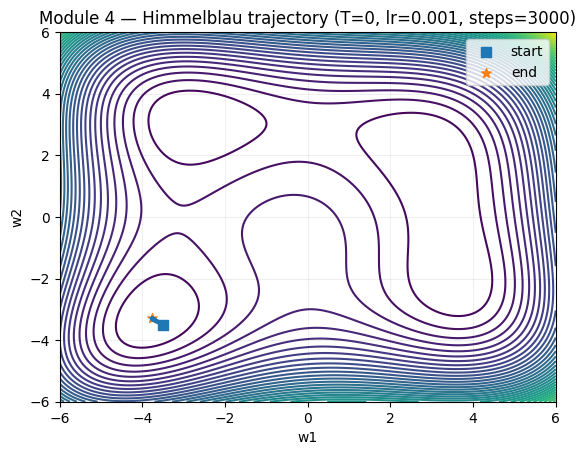

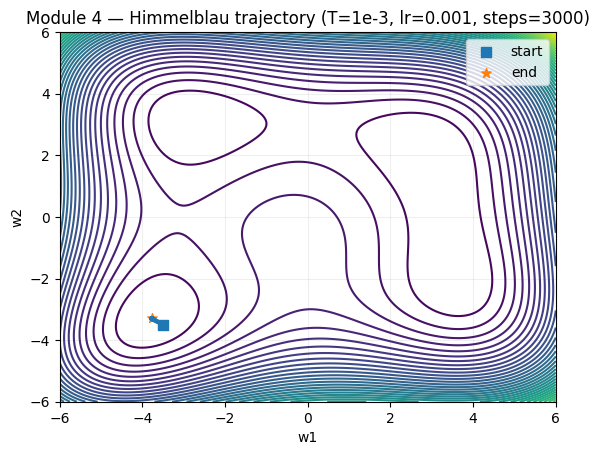

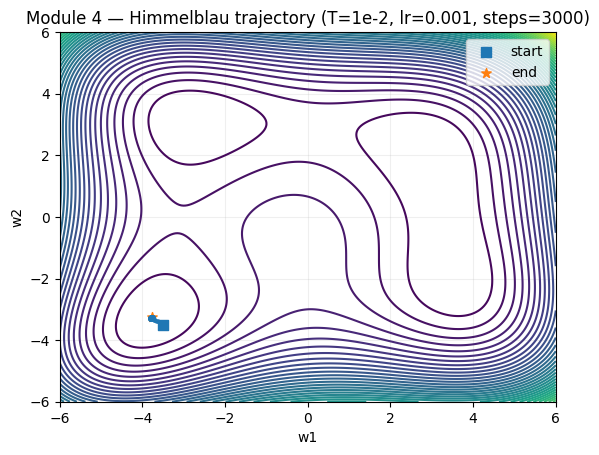

In [11]:
w0_2d = np.array([-3.5, -3.5])

lr = 1e-3
steps = 3000

traj_T0 = run_sgld(w0_2d, lr=lr, steps=steps, T=0.0, seed=0)
traj_T1 = run_sgld(w0_2d, lr=lr, steps=steps, T=1e-3, seed=0)
traj_T2 = run_sgld(w0_2d, lr=lr, steps=steps, T=1e-2, seed=0)

# Contour + trajectories
contour_with_trajectory(
    himmelblau, xlim=(-6, 6), ylim=(-6, 6), traj=traj_T0,
    title=f"Module 4 — Himmelblau trajectory (T=0, lr={lr}, steps={steps})",
    levels=45
)

contour_with_trajectory(
    himmelblau, xlim=(-6, 6), ylim=(-6, 6), traj=traj_T1,
    title=f"Module 4 — Himmelblau trajectory (T=1e-3, lr={lr}, steps={steps})",
    levels=45
)

contour_with_trajectory(
    himmelblau, xlim=(-6, 6), ylim=(-6, 6), traj=traj_T2,
    title=f"Module 4 — Himmelblau trajectory (T=1e-2, lr={lr}, steps={steps})",
    levels=45
)


### What do you observe? (Module 4)

1. With `T=0`, which basin/minimum does the trajectory approach from the chosen start?
2. With `T=1e-3`, do you see occasional deviations or “random walk” behavior?
3. With `T=1e-2`, does the trajectory still settle, or does it keep wandering?

### Expected takeaway
- `T=0` behaves like deterministic gradient descent on this surface (converges to a nearby basin).
- Small `T>0` adds mild exploration; it can sometimes help escape shallow basins.
- Too large `T` injects too much noise → the method may not converge (keeps diffusing).


## MODULE 5 — Micro reflection (3–5 min)

### Reflection questions (write 1–2 sentences each)
1. In Module 2, how did batch size change the “shape” of the loss curve? Why?
2. In Module 3, what did momentum change geometrically about the parameter path?
3. In Module 4, what is the practical meaning of “temperature” in SGLD?

### Mini checklist: tuning SGD in practice (quick)
- Start with a reasonable `lr` and test stability (loss decreasing, not exploding).
- Choose a batch size that fits compute constraints and provides acceptable noise.
- Add momentum to reduce zig-zagging; retune `lr` if needed.
- Monitor gradient norms and loss curves for signs of instability.
- Use a fixed random seed when debugging, then remove it for robustness checks.


## Wrap-up — Key takeaways

- Empirical risk is an average of per-sample losses; full-batch GD uses the exact gradient of this average.
- SGD replaces the full gradient with a noisy mini-batch estimate; noise magnitude decreases with batch size.
- Smaller batches can speed up iteration throughput but produce noisier, less stable optimization trajectories.
- Momentum adds a velocity that accumulates consistent gradient directions, reducing zig-zagging in narrow valleys.
- Nesterov uses a lookahead gradient; it can improve responsiveness in curved landscapes.
- SGLD adds temperature-scaled Gaussian noise, enabling exploration on non-convex objectives.
- Too much noise (large `T` or large `lr`) prevents convergence; small noise can help avoid poor local minima.
- Visual diagnostics (loss curves + parameter trajectories) are powerful for understanding optimization behavior.


## SGD debugging & tuning checklist

Use this when your training is unstable, too slow, or converges poorly:

1. **Learning rate (`lr`) sanity:** does the loss decrease at all? If exploding → lower `lr`.
2. **Scale check:** normalize features or ensure gradients are not huge due to data scaling.
3. **Batch size:** try {small, medium, large}; observe noise vs stability trade-off.
4. **Momentum (`mu`):** start at 0.9; if unstable, reduce `lr` or reduce `mu`.
5. **Nesterov:** compare with momentum; can be slightly more stable at similar speed (not guaranteed).
6. **Gradient norms:** track `||g||`; sudden spikes often signal too-large `lr` or outliers.
7. **Loss curve shape:** bumpy (SGD noise) is normal; upward trend is not.
8. **Initialization:** try different `w0`; some problems are sensitive to start points.
9. **Shuffling:** ensure you shuffle data each epoch; non-shuffled SGD can be biased.
10. **Seeds for debugging:** fix random seeds to reproduce behavior; then test multiple seeds.
11. **Learning rate schedules:** if plateauing, consider step decay or cosine decay (conceptually).
12. **Check implementation:** verify gradient formula with finite differences on a tiny test.
13. **SGLD temperature:** if using noise, keep `T` small; too large prevents settling.
14. **Compute budget alignment:** compare “epochs” vs “update steps” fairly across batch sizes.


## Concept questions (answer briefly)

1. Why is SGD “noisy”? What exactly is random in the update?
2. What is the main trade-off when increasing batch size?
3. Geometrically (informal), what does momentum do to the parameter trajectory?
4. How does Nesterov differ from classical momentum (in one sentence)?
5. In SGLD, what does “temperature” control? What happens if it is too large?
6. Why can adding noise sometimes help on non-convex objectives, but hurt final convergence?


## Optional extension (if you finish early)

- Try a larger learning rate in Module 3 and see which method diverges first.
- Try a smaller learning rate in Module 4 and compare SGLD trajectories again.
- Modify the synthetic regression noise level `noise_sigma` and see how optimization curves change.
- Plot the distance to `true_w` over time: `||w_k - true_w||` for GD vs SGD vs momentum.
